In [1]:
from PIL import Image
import argparse, os, sys, glob, json
import cv2
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

from ldm.data.open_images import get_tensor, get_tensor_clip, get_bbox_tensor, bbox2mask, mask2bbox


clip_transform = get_tensor_clip(image_size=(224, 224))
sd_transform   = get_tensor(image_size=(512, 512))
mask_transform = get_tensor(normalize=False, image_size=(512, 512))
def get_background(bg_path, loc_bbox):
    """
    input:
        bg_path: str - background image path
        loc_bbox: list [x1, y1, x2, y2] (xyxy)

    return:
        - background_img: PIL.Image (512, 512)
        - new_loc_bbox: list [x1, y1, x2, y2] in resized image
    """
    img = Image.open(bg_path).convert("RGB")
    W, H = img.size

    x1, y1, x2, y2 = loc_bbox
    assert x2 > x1 and y2 > y1, "Invalid bbox"

    # ---- Step 1: largest possible square ----
    square_size = min(W, H)

    # bbox center
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # initial crop (centered at bbox)
    crop_x1 = int(cx - square_size / 2)
    crop_y1 = int(cy - square_size / 2)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # ---- Step 2: clamp to image boundary ----
    if crop_x1 < 0:
        crop_x1 = 0
        crop_x2 = square_size
    if crop_y1 < 0:
        crop_y1 = 0
        crop_y2 = square_size
    if crop_x2 > W:
        crop_x2 = W
        crop_x1 = W - square_size
    if crop_y2 > H:
        crop_y2 = H
        crop_y1 = H - square_size

    # ---- Step 3: crop ----
    cropped_img = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))

    # ---- Step 4: bbox in cropped image ----
    new_x1 = x1 - crop_x1
    new_y1 = y1 - crop_y1
    new_x2 = x2 - crop_x1
    new_y2 = y2 - crop_y1

    # ---- Step 5: resize ----
    target_size = 512
    scale = target_size / square_size

    resized_img = cropped_img.resize(
        (target_size, target_size), Image.BILINEAR
    )

    new_loc_bbox = [
        int(new_x1 * scale),
        int(new_y1 * scale),
        int(new_x2 * scale),
        int(new_y2 * scale),
    ]

    return resized_img, new_loc_bbox


def get_foreground(fg_path, fg_mask_path, exam_bbox):
    """
    Crop fg_img và fg_mask_img theo exam_bbox, đảm bảo crop hình vuông.
    
    Args:
        fg_path (str): path tới ảnh foreground
        fg_mask_path (str): path tới ảnh mask tương ứng
        exam_bbox (tuple): (x_min, y_min, x_max, y_max)
    
    Returns:
        fg_crop (PIL.Image): foreground sau khi crop
        mask_crop (PIL.Image): mask sau khi crop
    """

    # Load images
    fg_img = Image.open(fg_path).convert("RGB")
    fg_mask = Image.open(fg_mask_path).convert("RGB")

    img_w, img_h = fg_img.size
    x_min, y_min, x_max, y_max = exam_bbox

    # Tính tâm bbox
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # Kích thước hình vuông
    box_w = x_max - x_min
    box_h = y_max - y_min
    side = int(max(box_w, box_h))

    # Toạ độ crop vuông
    left   = int(cx - side / 2)
    top    = int(cy - side / 2)
    right  = left + side
    bottom = top + side

    # Clamp để không vượt biên ảnh
    left   = max(0, left)
    top    = max(0, top)
    right  = min(img_w, right)
    bottom = min(img_h, bottom)

    # Crop
    fg_crop = fg_img.crop((left, top, right, bottom))
    mask_crop = fg_mask.crop((left, top, right, bottom))

    return fg_crop, mask_crop


def generate_image_batch(img_folder_path):
    bg_path = os.path.join(img_folder_path, 'ground_truth.jpg')
    fg_path = bg_path
    fg_mask_path = os.path.join(img_folder_path, 'mask_1.png')
    anno_path = os.path.join(img_folder_path, 'annotation.json')
    with open(anno_path, 'r') as f:
        anno = json.load(f)
    # chỉ lấy các trường hợp có hơn 2 mask obj
    if len(anno["inpainted_bboxes"])<=1:
        return None
    # get location bbox
    loc_bbox = anno["inpainted_bboxes"][0]
    # get examplar bbox
    exam_bbox = anno["inpainted_bboxes"][1]

    bg_img, bbox = get_background(bg_path, loc_bbox)
    bg_w, bg_h = bg_img.size
    bg_t       = sd_transform(bg_img)

    fg_img, fg_mask = get_foreground(fg_path, fg_mask_path, exam_bbox)
    black  = np.zeros_like(fg_mask)
    fg_mask= np.asarray(fg_mask)
    fg_img = np.asarray(fg_img)
    fg_img = np.where(fg_mask > 127, fg_img, black)
    fg_img = Image.fromarray(fg_img)

    fg_t       = clip_transform(fg_img)
    mask       = Image.fromarray(bbox2mask(bbox, bg_w, bg_h))
    mask_t     = mask_transform(mask)
    mask_t     = torch.where(mask_t > 0.5, 1, 0).float()
    inpaint_t  = bg_t * (1 - mask_t)
    bbox_t     = get_bbox_tensor(bbox, bg_w, bg_h)

    return {"bg_img":  inpaint_t.unsqueeze(0),
            "bg_mask": mask_t.unsqueeze(0),
            "fg_img":  fg_t.unsqueeze(0),
            "bbox":    bbox_t.unsqueeze(0)
            }


/mnt/disk1/aiotlab/envs/composition/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
bbox = [
      494,
      227,
      580,
      313
    ]
resized_img, new_loc_bbox = get_background(
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/ground_truth.jpg',
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/mask_2.png',
    bbox
)


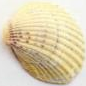

In [6]:
bbox = [
      494,
      227,
      580,
      313
    ]
fg_crop, mask_crop = get_foreground(
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/ground_truth.jpg',
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/mask_2.png',
    bbox
)
fg_crop

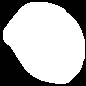

In [7]:
mask_crop

In [11]:
def get_background(bg_path, all_bboxes, loc_bbox, exam_bbox):
    """
    input:
        bg_path: str - background image path
        all_bboxes: list<[x1, y1, x2, y2]> (xyxy)
        loc_bbox: [x1, y1, x2, y2] (xyxy)
        exam_bbox:[x1, y1, x2, y2] (xyxy)

    return:
        - background_img: PIL.Image (512, 512)
        - fit_bboxes_resize: list<[x1, y1, x2, y2]> in resized image
    """
    img = Image.open(bg_path).convert("RGB")
    W, H = img.size

    x1, y1, x2, y2 = loc_bbox
    assert x2 > x1 and y2 > y1, "Invalid bbox"

    # ---- Step 1: largest possible square ----
    square_size = min(W, H)

    # bbox center
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # initial crop (centered at bbox)
    crop_x1 = int(cx - square_size / 2)
    crop_y1 = int(cy - square_size / 2)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # ---- Step 2: clamp to image boundary ----
    if crop_x1 < 0:
        crop_x1 = 0
        crop_x2 = square_size
    if crop_y1 < 0:
        crop_y1 = 0
        crop_y2 = square_size
    if crop_x2 > W:
        crop_x2 = W
        crop_x1 = W - square_size
    if crop_y2 > H:
        crop_y2 = H
        crop_y1 = H - square_size

    # ---- Step 3: crop ----
    cropped_img = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))

    # ---- Step 4: bbox in cropped image ----
    new_x1 = x1 - crop_x1
    new_y1 = y1 - crop_y1
    new_x2 = x2 - crop_x1
    new_y2 = y2 - crop_y1

    # ---- Lấy các bbox còn lại vẫn nằm trong ảnh cropped image ----
    fit_bboxes = []
    for bbox in all_bboxes:
        if bbox != exam_bbox and bbox != loc_bbox:
            b_x1, b_y1, b_x2, b_y2 = bbox
            new_b_x1 = b_x1 - crop_x1
            new_b_y1 = b_y1 - crop_y1
            new_b_x2 = b_x2 - crop_x1
            new_b_y2 = b_y2 - crop_y1

            if new_b_x1>=0 and new_b_y1>=0 and new_b_x2<=square_size and new_b_y2<=square_size:
                new_bbox = [new_b_x1, new_b_y1, new_b_x2, new_b_y2]
                fit_bboxes.append(new_bbox)

    # ---- Step 5: resize ----
    target_size = 512
    scale = target_size / square_size

    resized_img = cropped_img.resize(
        (target_size, target_size), Image.BILINEAR
    )

    new_loc_bbox = [
        int(new_x1 * scale),
        int(new_y1 * scale),
        int(new_x2 * scale),
        int(new_y2 * scale),
    ]

    fit_bboxes_resize = [new_loc_bbox]
    for bbox in fit_bboxes:
        b_x1, b_y1, b_x2, b_y2 = bbox
        new_fit_bbox = [
            int(b_x1 * scale),
            int(b_y1 * scale),
            int(b_x2 * scale),
            int(b_y2 * scale),
        ]
        fit_bboxes_resize.append(new_fit_bbox)

    return resized_img, fit_bboxes_resize

In [14]:
bg_path = '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/300_b2/ground_truth.jpg'
all_bboxes = [
    [
      100,
      98,
      171,
      172
    ],
    [
      75,
      35,
      154,
      112
    ],
    [
      48,
      111,
      108,
      181
    ],
    [
      44,
      173,
      123,
      252
    ],
    [
      35,
      245,
      114,
      313
    ],
    [
      86,
      294,
      158,
      362
    ],
    [
      156,
      283,
      234,
      364
    ],
    [
      223,
      253,
      297,
      328
    ],
    [
      190,
      202,
      270,
      269
    ],
    [
      199,
      145,
      258,
      205
    ],
    [
      238,
      105,
      306,
      174
    ],
    [
      158,
      78,
      246,
      153
    ],
    [
      148,
      29,
      220,
      91
    ],
    [
      213,
      39,
      286,
      108
    ],
    [
      331,
      66,
      394,
      134
    ],
    [
      368,
      34,
      427,
      89
    ],
    [
      392,
      75,
      458,
      139
    ],
    [
      342,
      128,
      406,
      178
    ],
    [
      341,
      159,
      417,
      242
    ],
    [
      348,
      244,
      418,
      324
    ],
    [
      406,
      130,
      478,
      197
    ],
    [
      457,
      93,
      522,
      169
    ],
    [
      501,
      57,
      560,
      127
    ],
    [
      429,
      38,
      487,
      94
    ],
    [
      513,
      195,
      601,
      263
    ],
    [
      465,
      166,
      533,
      233
    ],
    [
      511,
      118,
      578,
      188
    ],
    [
      463,
      232,
      530,
      287
    ],
    [
      497,
      273,
      560,
      346
    ],
    [
      410,
      266,
      499,
      353
    ],
    [
      407,
      195,
      478,
      268
    ],
    [
      112,
      223,
      206,
      299
    ],
    [
      119,
      160,
      203,
      228
    ]
  ]
loc_bbox = [
      223,
      253,
      297,
      328
    ]
exam_bbox = [
      158,
      78,
      246,
      153
    ]

resized_img, fit_bboxes_resize= get_background(bg_path, all_bboxes, loc_bbox, exam_bbox)

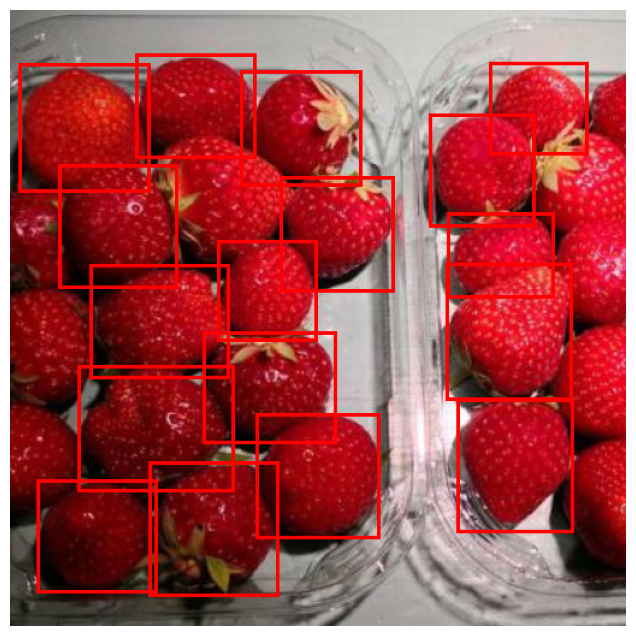

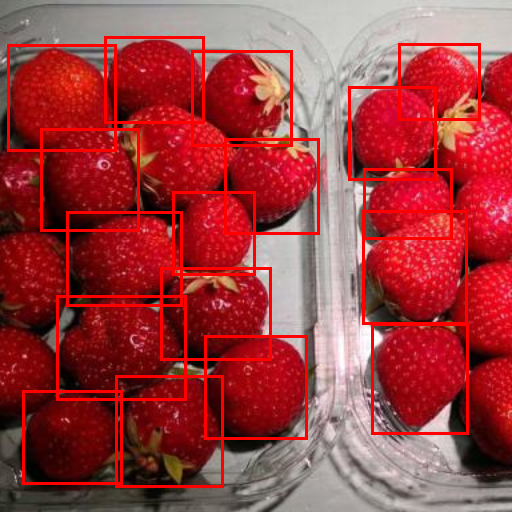

In [15]:
visualize(resized_img, fit_bboxes_resize)

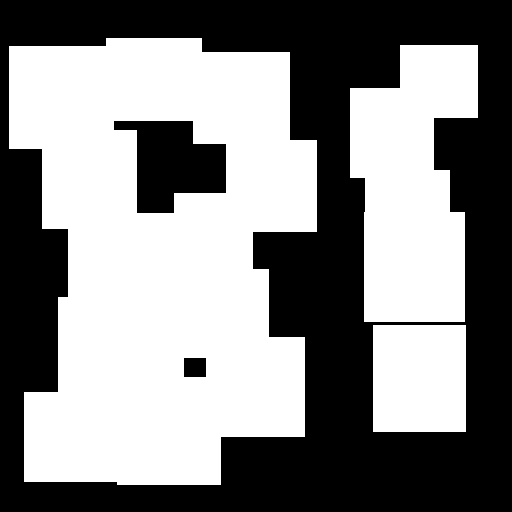

In [18]:
import numpy as np
def bboxes2mask(bboxes, mask_w, mask_h):
    mask = np.zeros((mask_h, mask_w), dtype=np.uint8)

    for bbox in bboxes:
        x1, y1, x2, y2 = bbox
        mask[y1:y2, x1:x2] = 255

    return mask

Image.fromarray(bboxes2mask(fit_bboxes_resize, 512, 512))

## Visualize

In [6]:
from PIL import ImageDraw, Image

import matplotlib.pyplot as plt

def visualize(img, boxes, labels=None, outline='red', width=3, figsize=(8,8), show=True):
    """
    Draw boxes on an image and display using matplotlib.

    Args:
        img: PIL.Image.Image, numpy array, or path to image.
        boxes: list of [x1, y1, x2, y2]
        labels: optional list of strings (same length as boxes)
        outline: box color
        width: box line thickness
        figsize: matplotlib figure size
        show: if True, display the image

    Returns:
        PIL.Image with drawn boxes.
    """
    # normalize image to PIL.Image
    if isinstance(img, str):
        img = Image.open(img).convert("RGB")
    elif not isinstance(img, Image.Image):
        img = Image.fromarray(img)

    draw = ImageDraw.Draw(img)
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        # draw thicker rectangle by drawing multiple offsets
        for w in range(width):
            draw.rectangle([x1-w, y1-w, x2+w, y2+w], outline=outline)
        # draw label if provided
        if labels and i < len(labels):
            text = labels[i]
            text_pos = (x1, max(0, y1 - 10))
            draw.text(text_pos, text, fill=outline)

    if show:
        plt.figure(figsize=figsize)
        plt.axis('off')
        plt.imshow(img)
        plt.show()

    return img

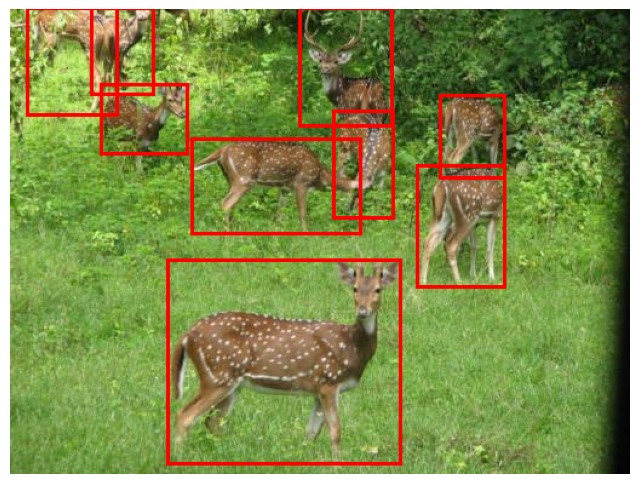

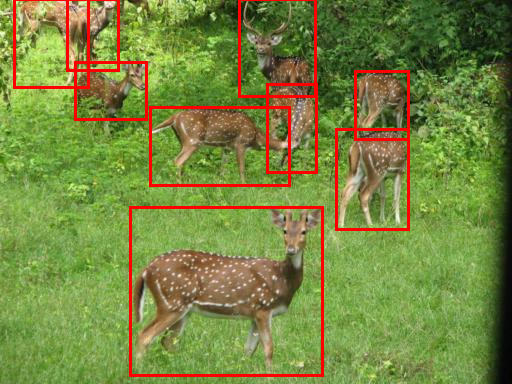

In [20]:
image_path ='/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2615_b3/ground_truth.jpg'
boxes1 = [
    [
      310,
      126,
      316,
      134
    ]
]
boxes2 = [
    [
      131,
      208,
      321,
      374
    ],
    [
      337,
      130,
      407,
      228
    ],
    [
      356,
      72,
      407,
      138
    ],
    [
      151,
      108,
      288,
      184
    ],
    [
      76,
      63,
      145,
      118
    ],
    [
      268,
      85,
      315,
      171
    ],
    [
      240,
      0,
      314,
      95
    ],
    [
      15,
      0,
      87,
      86
    ],
    [
      68,
      0,
      117,
      69
    ]
  ]


visualize(image_path, boxes2)

In [5]:
x1=2
x2=3
a = [x1,x2]
y1, y2 = a
y1=4
b = [2,3]
a==b

True

## Sửa dữ liệu

In [19]:
import json
import os
import sys

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    inter = interW * interH
    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def coord_similarity(boxA, boxB):
    # normalize coordinate diffs by boxA size
    w = max(1.0, boxA[2] - boxA[0])
    h = max(1.0, boxA[3] - boxA[1])
    diffs = [abs(boxA[0]-boxB[0])/w, abs(boxA[1]-boxB[1])/h,
             abs(boxA[2]-boxB[2])/w, abs(boxA[3]-boxB[3])/h]
    sim = 1.0 - (sum(diffs)/4.0)
    return max(0.0, sim)

def find_best_match(target, candidates):
    best_idx = None
    best_score = -1.0
    for i, c in enumerate(candidates):
        s_iou = iou(target, c)
        s_coord = coord_similarity(target, c)
        score = max(s_iou, s_coord)
        if score > best_score:
            best_score = score
            best_idx = i
    return best_idx, best_score

def main(path_str, threshold=0.99):
    for img_folder in os.listdir(path_str):
        anno_path = os.path.join(path_str, img_folder, 'annotation.json')
        new_anno_path = os.path.join(path_str, img_folder, 'fixed_annotation.json')

        # load anno
        with open(anno_path, 'r') as f:
            data = json.load(f)
        inpainted = data.get("inpainted_bboxes", [])
        all_bboxes = data.get("all_bboxes", [])
        if not inpainted:
            print(f"{img_folder} : No inpainted_bboxes found.")
        
        # gán lại giá trị cho các bbox ở inpainted_bboxes sẽ có trong all_bboxes
        target = inpainted[0]
        idx, score = find_best_match(target, all_bboxes)
        if idx is None:
            print(f"{img_folder} : No candidates found in all_bboxes.")

        if score >= threshold:
            all_bboxes[idx] = data["inpainted_bboxes"][0]
            
        else:
            all_bboxes.append(data["inpainted_bboxes"][0])

        with open(new_anno_path, 'w') as f:
                json.dump(data, f, indent=2)

if __name__ == "__main__":
    path = '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/val'
    thr = 0.2
    main(path, thr)